# DATA ANALYSIS

# Lodaing dataset

In [14]:
# ==== IMPORSTS & SETTINGS ====
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# ==== FUNCTION ====
def load_csv_to_df(csv_path, sep=";"):
    try:
        df = pd.read_csv(csv_path, encoding="utf-8", sep=sep)
        print(f"Successfully loaded CSV from {csv_path}")
        print(f"DataFrame shape: {df.shape}")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading CSV from {csv_path}: {e}")
        return None

def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# ==== DEFINE PATHS ====
data_path = "../Data/gcp_order/dtu_findit/extraction_and_processing/"

# ==== DEFINE FILES ====
file1 = "thesis_meta_added_equations_to_olivers_26032026.parquet"
file2 = "thesis_meta_added_linguistics_to_olivers_26032026.parquet"
file3 = "thesis_meta_added_supervisors_26032026.parquet"
file4 = "thesis_meta_all_metrics_except_grade_27032026.parquet"
file5 = "thesis_meta_all_metrics_except_grade_filtered_27032026.parquet"

# ==== LOAD DATAFRAMES ====
#print("df1:")
#df1 = load_parquet_to_df(data_path + file1)
#print("df2:")
#df2 = load_parquet_to_df(data_path + file2)
#print("df3:")
#df3 = load_parquet_to_df(data_path + file3)
df_all = load_parquet_to_df(data_path + file4)
df_filtered = load_parquet_to_df(data_path + file5)

# ==== DROP NA COLUMNS ====
df_all_noNA = df_all.dropna(axis=1, how="all")
print(f"df_all_noNA shape: {df_all_noNA.shape}")
print(f"df_all_noNA columns: {df_all_noNA.columns.tolist()}\n")
df_filtered_noNA = df_filtered.dropna(axis=1, how="all")
print(f"df_filtered_noNA shape: {df_filtered_noNA.shape}")
print(f"df_filtered_noNA columns: {df_filtered_noNA.columns.tolist()}\n")

# ==== COLUMNS TO DROP ====
drop_columns = [
    "access_ss",
    "Affiliations",
    "collection_facet",
    "format",
    "fulltext_availability_facet",
    "ISBN",
    "Journal Page",
    "isolanguage_facet",
    "Publisher",
    "Source",
    "source_all_ss",
    "match_trigger",
    "equation_pipeline_version",
    "pdf_file_analysis",
    "num_tot_pages_analysis",
    "num_cont_pages_analysis",
    "num_words_full_analysis",
    "num_words_cont_analysis",
    "abstract_ts_analysis",
    "Author_analysis",
    "Publication Year_analysis",
    "primary_member_id_s_analysis",
    "Title_analysis",
    ]

# ==== DROP COLUMNS ====
df_all_noNA_clean = df_all_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_all_noNA_clean shape: {df_all_noNA_clean.shape}")
print(f"df_all_noNA_clean columns: {df_all_noNA_clean.columns.tolist()}\n")
df_filtered_noNA_clean = df_filtered_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_filtered_noNA_clean shape: {df_filtered_noNA_clean.shape}")
print(f"df_filtered_noNA_clean columns: {df_filtered_noNA_clean.columns.tolist()}\n")

# ==== LOCK DATAFRAMES FOR ANALYSIS ====
print("Final DataFrames for Analysis:")
df_all_final = df_all_noNA_clean.copy()
print(f"df_all_final shape: {df_all_final.shape}")
df_filtered_final = df_filtered_noNA_clean.copy()
print(f"df_filtered_final shape: {df_filtered_final.shape}")

Successfully loaded Parquet from ../Data/gcp_order/dtu_findit/extraction_and_processing/thesis_meta_all_metrics_except_grade_27032026.parquet
DataFrame shape: (19690, 76)
DataFrame columns: ['abstract_ts', 'access_ss', 'Affiliations', 'Timestamp', 'Author', 'citation_count_i', 'ID', 'dtu_library_collection_facet', 'collection_facet', 'Publication Year', 'Conference', 'DOI', 'Editor', 'embargo_ssf', 'format', 'fulltext_availability_facet', 'has_openaccess_fulltext_b', 'holdings_ssf', 'ISBN', 'Journal Issue', 'journal_issue_tsort', 'journal_oa_model_ss', 'Journal Page', 'journal_page_start_tsort', 'Journal Title', 'journal_title_facet', 'toc_key_s', 'Journal Volume', 'journal_vol_tsort', 'keywords_ts', 'keywords_facet', 'keywords_normalized', 'isolanguage_facet', 'member_id_ss', 'ORCID', 'primary_member_id_s', 'Publisher', 'Source', 'source_all_ss', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'YEAR', 'PUBLISHER', 'TYPES', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_wor

In [15]:
df_filtered_final.head()

,Timestamp,Author,ID,Publication Year,member_id_ss,primary_member_id_s,Title,MASTER THESIS TITLE,BY,SUPERVISED BY,pdf_file,num_tot_pages,num_cont_pages,num_words_full,num_words_cont,handin_month,num_figures,num_tables,num_references,equation_count,pdf_sha256,total_sentences,total_words,unique_words,avg_sentence_length,avg_word_length,lexical_diversity,Department_new,grading_scientific_contribution,grading_methodological_rigor,grading_technical_implementation,grading_literature_review,grading_process_professionalism,grading_impact_applicability,grading_research_question_alignment,grading_total_score,grading_meta_attempts,grading_meta_original_chars,grading_meta_trimmed_at_references,grading_meta_input_chars,grading_meta_estimated_input_tokens,grading_meta_was_truncated,grading_meta_prompt_fit_attempts,grading_meta_timeout_seconds,grading_meta_stream_mode
0,2025-02-26T01:51:41.171Z,"Uth, Matilde",2868333190,2025,67be6a2d56d32566d74defce,67be6a2d56d32566d74defce,Comparing long and short read technologies in ...,Comparing long and short read technologies in ...,"Uth, Matilde","Otani, Saria; Petersen, Thomas Nordahl",67be6a2d56d32566d74defce_Comparing long and sh...,53.0,40.0,12590.0,10828.0,January 2025,21.0,11.0,34.0,28.0,1737cf35faefaf79420cb133a8154b5c412cfdd7483c03...,581.0,10985.0,2177.0,18.91,5.06,0.198,DTU Food,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN
1,2025-02-26T01:51:40.290Z,"Gravesen, Johannes Bøgelund",2868333131,2025,67be6a16754a9d66d7be5fb3,67be6a16754a9d66d7be5fb3,Effect of Nozzle Geometry on a Water Mist Fire...,Effect of Nozzle Geometry on a Water Mist Fire...,"Gravesen, Johannes Bøgelund","Walther, Jens Honore; Meyer, Knud Erik",67be6a16754a9d66d7be5fb3_Effect of Nozzle Geom...,202.0,81.0,54624.0,35910.0,August 2024,151.0,17.0,36.0,27.0,ecfe448f438675253102e42ce1caf3c6e985613bdb40b8...,1421.0,34509.0,3280.0,24.29,4.61,0.095,DTU Construct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN
2,2025-08-14T00:09:36.887Z,"Deng, Siyuan",2872988369,2025,689d294027df7f01020cebe5,689d294027df7f01020cebe5,Vision-Based Process Mining: Event Extraction ...,Vision-Based Process Mining: Event Extraction ...,"Deng, Siyuan","López-Acosta, Hugo-Andrés",689d294027df7f01020cebe5_Vision-Based Process ...,68.0,58.0,22582.0,20794.0,June 2025,21.0,10.0,51.0,4.0,bb2234f0e0ed91418f283731b9d8bdb6ee91612e36665b...,1063.0,19430.0,3401.0,18.28,6.18,0.175,DTU Compute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN
3,2025-08-02T00:10:27.278Z,"Gereoudakis, Polyvios",2872712978,2025,688d57728e1e270102bab9b6,688d57728e1e270102bab9b6,Ultrafine Particle Pollution (UFP) in Indoor A...,Ultrafine Particle Pollution (UFP) in Indoor A...,"Gereoudakis, Polyvios","Mikkelsen, Teis Nørgaard",688d57728e1e270102bab9b6_Ultrafine Particle Po...,36.0,29.0,13843.0,11022.0,May 2025,15.0,5.0,73.0,4.0,9bbe4a4cba70298655767eccf3b687024dbd664e302b73...,449.0,10942.0,2187.0,24.37,5.65,0.200,DTU Sustain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN
4,2024-12-18T01:26:35.134Z,"Diez, Enrique Martínez",2854137646,2024,676220d877b049a804be5ce2,676220d877b049a804be5ce2,The role of germline variants in T cells respo...,The role of germline variants in T cells respo...,"Diez, Enrique Martínez","Nos, Grigorii; Hadrup, Sine Reker",676220d877b049a804be5ce2_The role of germline ...,23.0,16.0,3777.0,3299.0,November 2024,8.0,0.0,12.0,1.0,c9d2e399e65fdedb0c4a5c06878103db7c2fc4f0d28826...,129.0,3086.0,879.0,23.92,5.30,0.285,DTU Health Tech,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN


# Analysis

The DataFrames to use are:
- `df_all_final`
- `df_filtered_final`

## Exclude rows where Publication Year is 2026?

In [22]:
choice = input("Excluded rows with Publication Year == 2026? (Y/n): ").strip().lower()

if choice == "n":
    print("Keeping rows with Publication Year == 2026.")
else:
    # drop rows that has "Publication Year" == 2026
    print("df_all_final")
    df_all_final = df_all_final[df_all_final["Publication Year"] != 2026]
    excluded_rows_all = pd.to_numeric(df_all_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_all}")
    print(f"df_all_final shape after dropping rows with Publication Year == 2026: {df_all_final.shape}\n")
    
    print("df_filtered_final")
    df_filtered_final = df_filtered_final[df_filtered_final["Publication Year"] != 2026]
    excluded_rows_filtered = pd.to_numeric(df_filtered_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_filtered}")
    print(f"df_filtered_final shape after dropping rows with Publication Year == 2026: {df_filtered_final.shape}")


df_all_final
Number of rows dropped with Publication Year == 2026: 6
df_all_final shape after dropping rows with Publication Year == 2026: (19684, 32)

df_filtered_final
Number of rows dropped with Publication Year == 2026: 3
df_filtered_final shape after dropping rows with Publication Year == 2026: (6251, 45)


## Serching for trends around 2023 (realaese of ChatGPT)

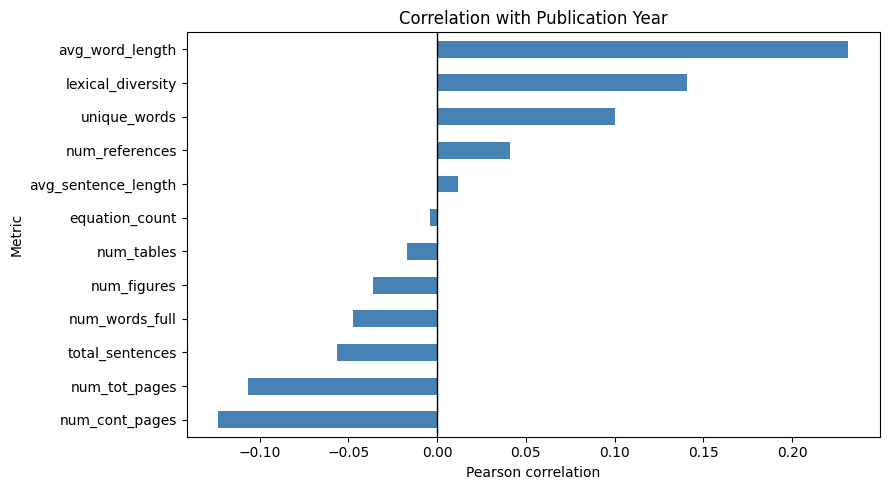

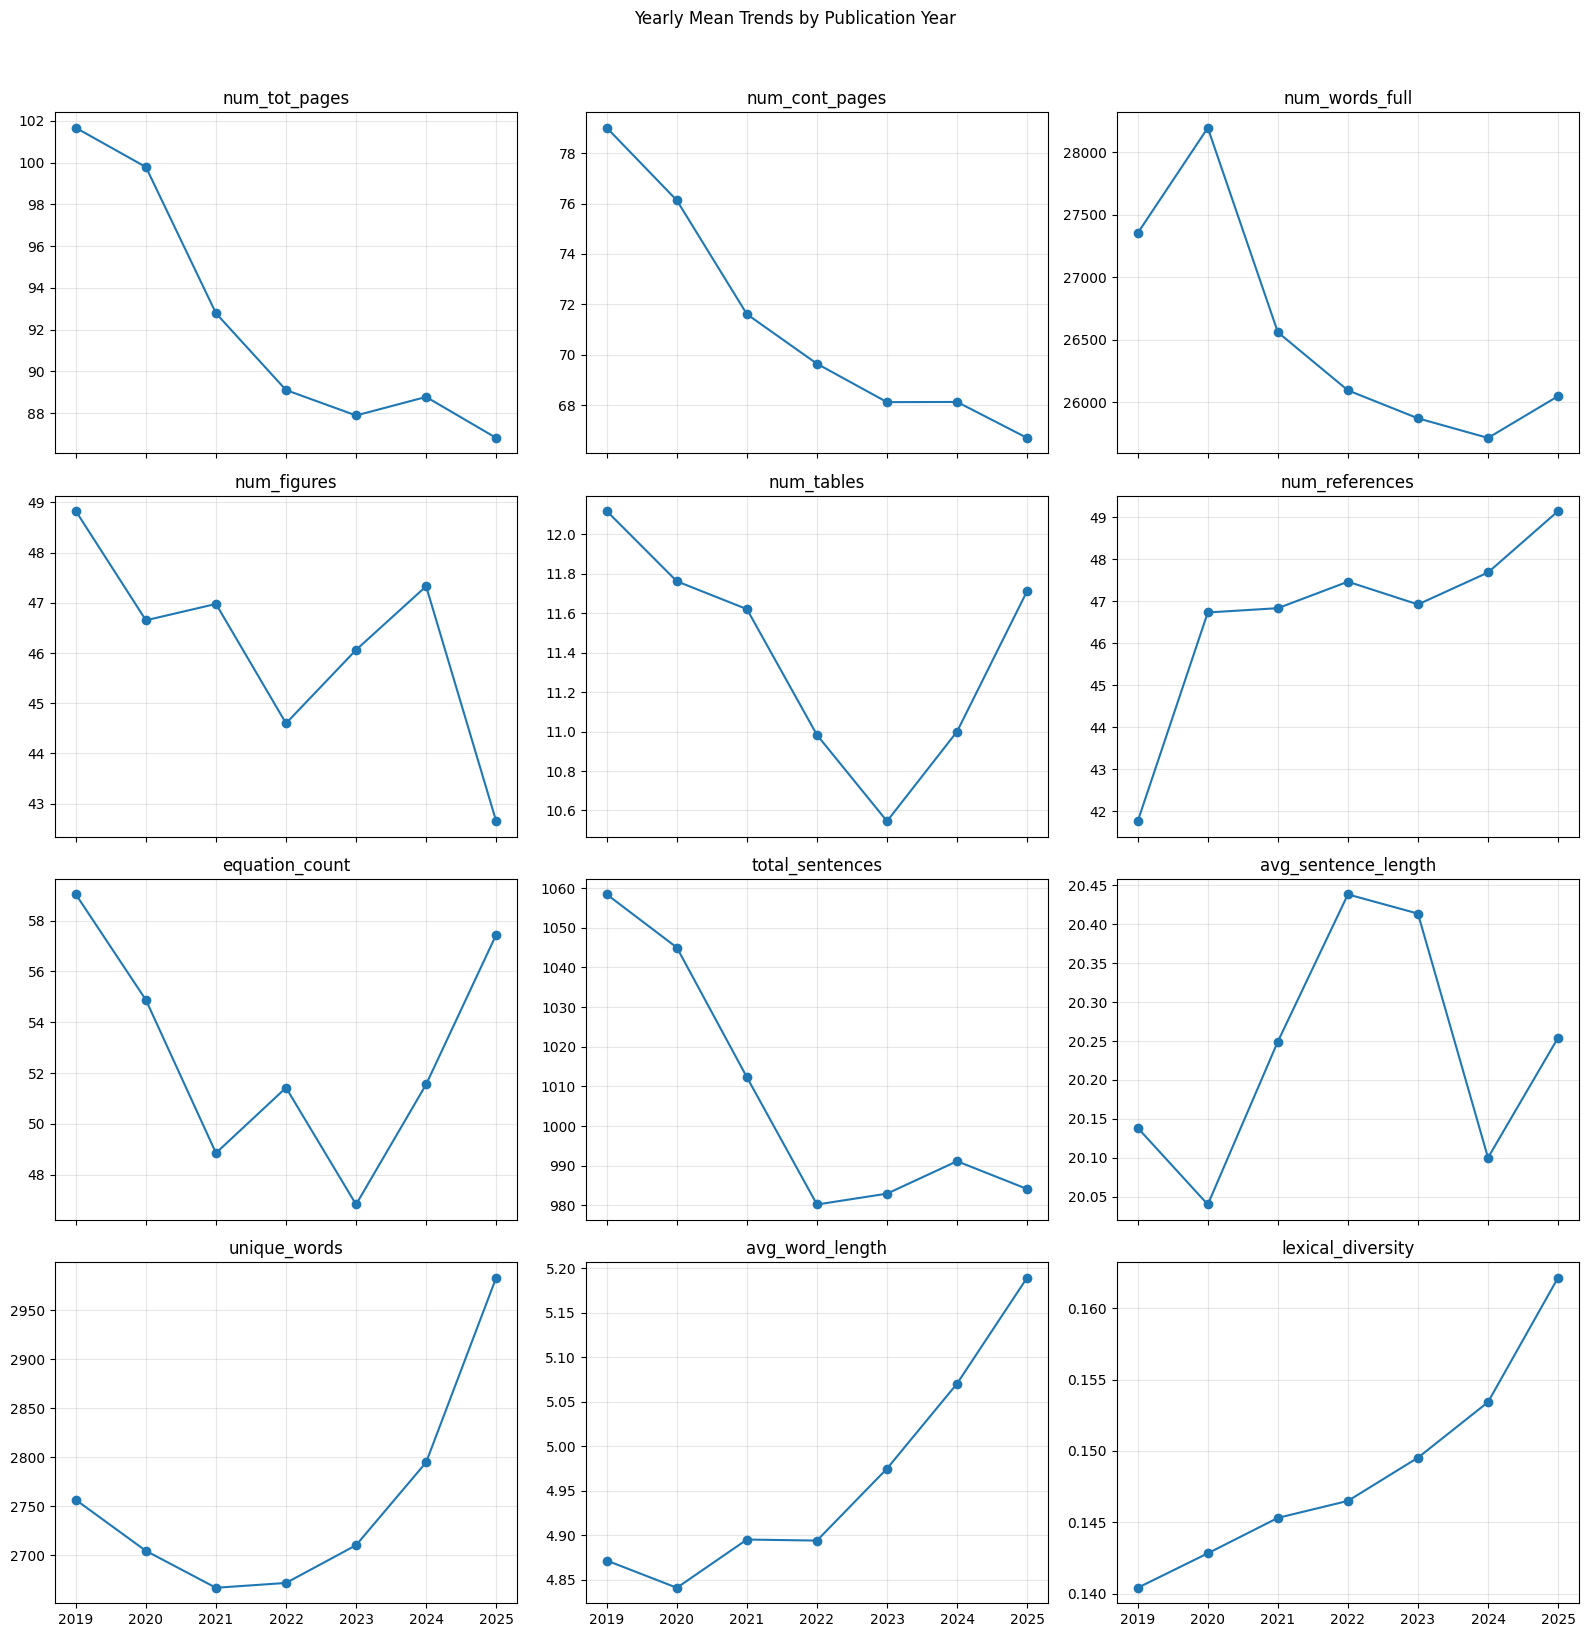

In [24]:
# Searching for trends around 2023 (using Publication Year)

source_df = df_filtered_final if "df_filtered_final" in globals() else df_filtered_noNA_clean

metrics = [
    "num_tot_pages",
    "num_cont_pages",
    "num_words_full",
    "num_figures",
    "num_tables",
    "num_references",
    "equation_count",
    "total_sentences",
    "avg_sentence_length",
    "unique_words",
    "avg_word_length",
    "lexical_diversity",
]

available_metrics = [m for m in metrics if m in source_df.columns]

df_plot = source_df.copy()

# Use Publication Year only
df_plot["Publication Year"] = pd.to_numeric(
    df_plot["Publication Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

for col in available_metrics:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

df_plot = df_plot.dropna(subset=["Publication Year"])
df_plot = df_plot[(df_plot["Publication Year"] >= 2000) & (df_plot["Publication Year"] <= 2030)]

corr_with_year = (
    df_plot[["Publication Year"] + available_metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.ylabel("Metric")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

yearly_means = (
    df_plot.groupby("Publication Year")[available_metrics]
    .mean(numeric_only=True)
    .sort_index()
)

n = len(available_metrics)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(available_metrics):
    axes[i].plot(yearly_means.index, yearly_means[col], marker="o", linewidth=1.5)
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Yearly Mean Trends by Publication Year", y=1.02)
fig.tight_layout()
plt.show()

Correlation of metrics with Total Pages:
num_tot_pages        1.000000
lexical_diversity   -0.368157
avg_word_length     -0.057391
num_references       0.197716
Name: num_tot_pages, dtype: float64


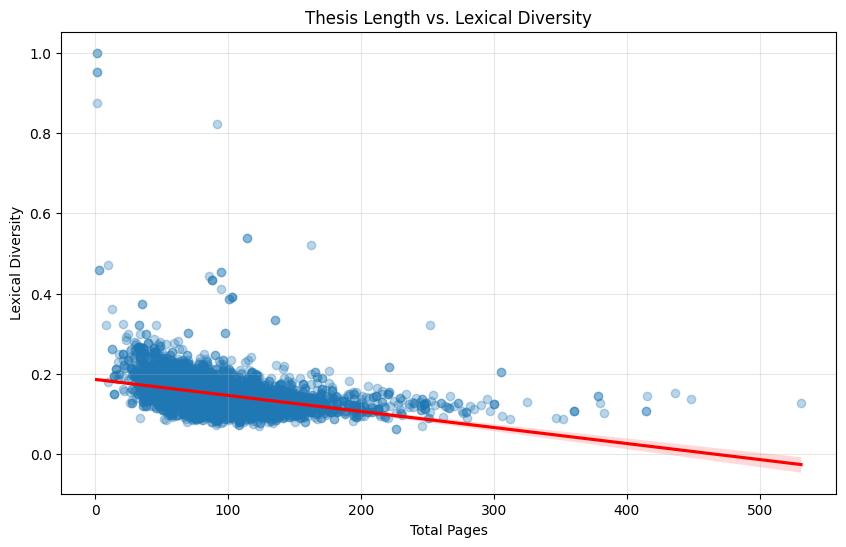

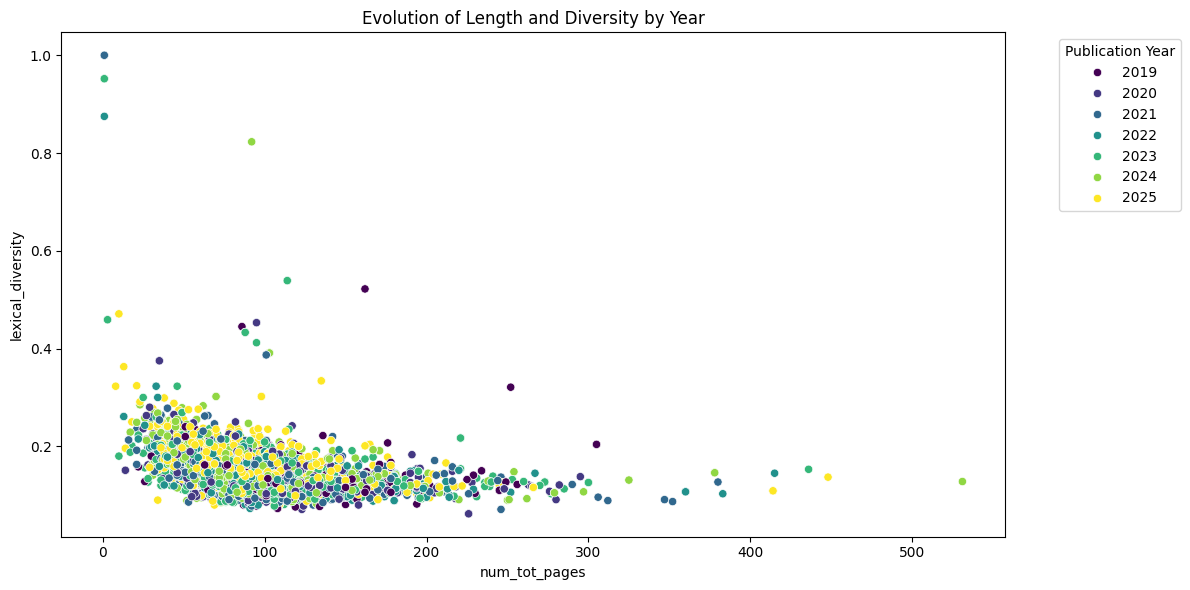


Yearly Mean Trends:
   Publication Year  num_tot_pages  lexical_diversity  avg_word_length
0              2019     101.666667           0.140415         4.871802
1              2020      99.788595           0.142829         4.841234
2              2021      92.785059           0.145312         4.895420
3              2022      89.107673           0.146502         4.894248
4              2023      87.890678           0.149531         4.975119
5              2024      88.777778           0.153423         5.070598
6              2025      86.814912           0.162142         5.189587


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is df_filtered_final
df = df_filtered_final.copy()

# 1. Statistical check: Is there a negative correlation?
# This tells us if shorter documents (lower pages) have higher complexity
density_metrics = ['num_tot_pages', 'lexical_diversity', 'avg_word_length', 'num_references']
correlation_matrix = df[density_metrics].corr()

print("Correlation of metrics with Total Pages:")
print(correlation_matrix['num_tot_pages'])

# 2. Visualizing the 'Density vs. Length' tradeoff
# The regression line will show the general trend across all years
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='num_tot_pages', y='lexical_diversity', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Thesis Length vs. Lexical Diversity')
plt.xlabel('Total Pages')
plt.ylabel('Lexical Diversity')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Analyzing the trend by year (Corrected column name)
# This will show if the 2024-2025 points are moving to the "High Diversity/Low Page" zone
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis'
)
plt.title('Evolution of Length and Diversity by Year')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Final confirmation of the "2023 Shift"
yearly_summary = df.groupby('Publication Year').agg({
    'num_tot_pages': 'mean',
    'lexical_diversity': 'mean',
    'avg_word_length': 'mean'
}).reset_index()

print("\nYearly Mean Trends:")
print(yearly_summary)

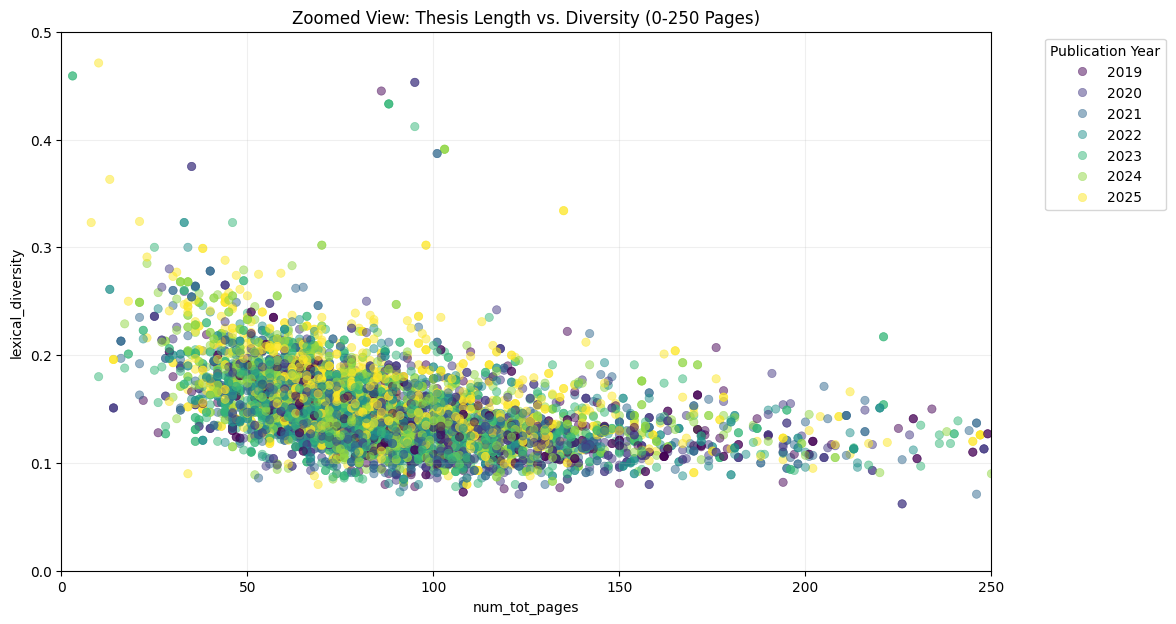

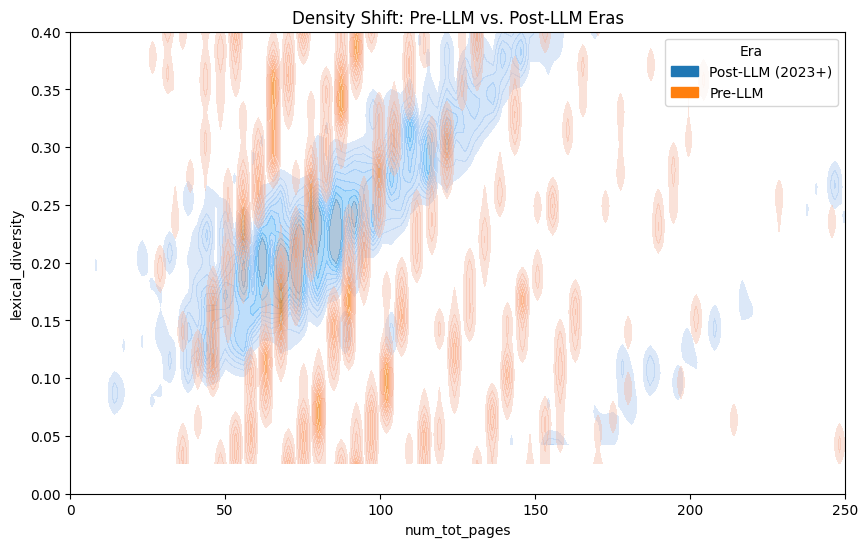

In [30]:
# 1. Zooming in on the dense area
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.5,     # Makes points transparent so you can see density
    edgecolor=None # Removes white borders around points for clarity
)

# Strategic limits based on your previous plot
plt.xlim(0, 250)  
plt.ylim(0, 0.5)  

plt.title('Zoomed View: Thesis Length vs. Diversity (0-250 Pages)')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

# 2. The "Before vs After" Comparison (The 'LLM Effect' Plot)
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.4
)
plt.title('Density Shift: Pre-LLM vs. Post-LLM Eras')
plt.xlim(0, 250)
plt.ylim(0, 0.4)
plt.show()

--- Median Metrics per Year ---
   Publication Year  num_tot_pages  lexical_diversity  avg_word_length  \
0              2019           93.0              0.134            4.805   
1              2020           93.0              0.136            4.860   
2              2021           84.0              0.137            4.900   
3              2022           79.5              0.141            4.900   
4              2023           80.0              0.142            4.980   
5              2024           83.0              0.145            5.030   
6              2025           78.0              0.158            5.200   

   num_references  
0            34.0  
1            39.0  
2            39.0  
3            42.0  
4            40.0  
5            42.0  
6            42.0  


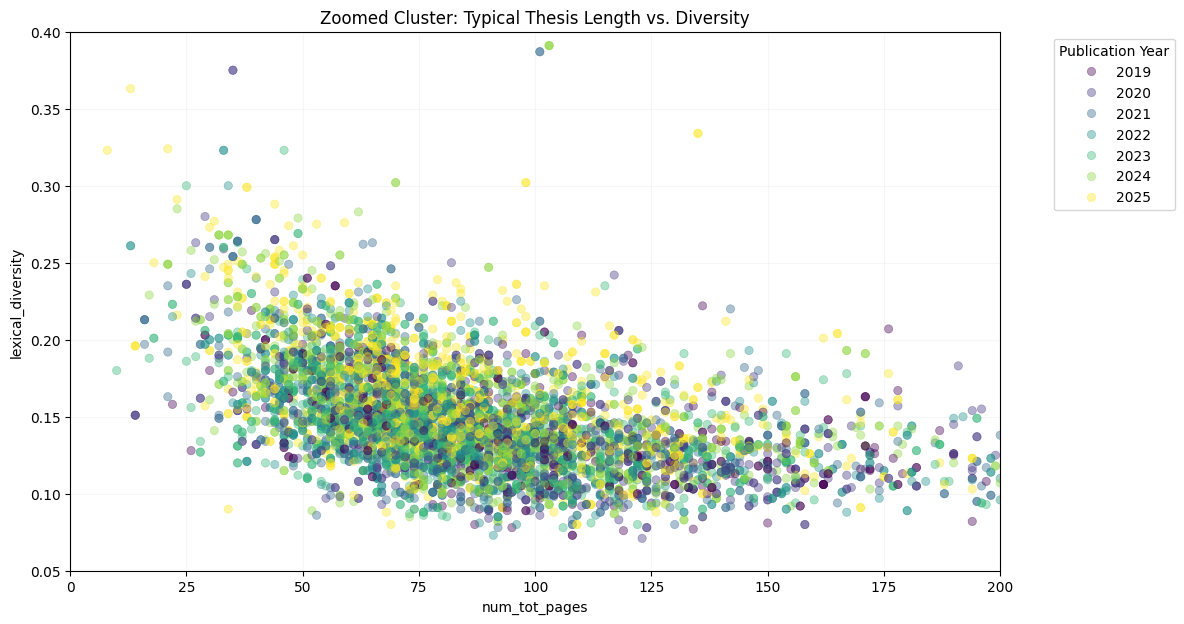

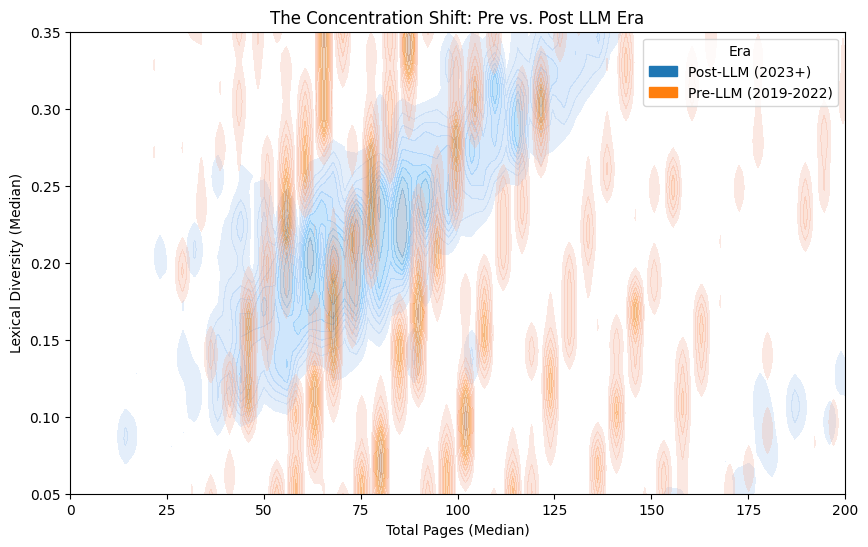

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df_filtered_final.groupby('Publication Year').agg({
    'num_tot_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# 2. Zoomed-In Scatter Plot
# We limit the axes to where 95% of the data lives (0-200 pages, 0.1-0.4 diversity)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.4,     # High transparency to see where points stack up
    edgecolor=None
)

plt.xlim(0, 200)   # Zooming in on the X-axis
plt.ylim(0.05, 0.4) # Zooming in on the Y-axis
plt.title('Zoomed Cluster: Typical Thesis Length vs. Diversity')
plt.grid(True, alpha=0.1)
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. The "Era Shift" Density Plot
# This turns the "muddy" dots into a heatmap of concentration
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM (2019-2022)'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.3,
    common_norm=False # This ensures each era is normalized independently
)

plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Pages (Median)')
plt.ylabel('Lexical Diversity (Median)')
plt.show()

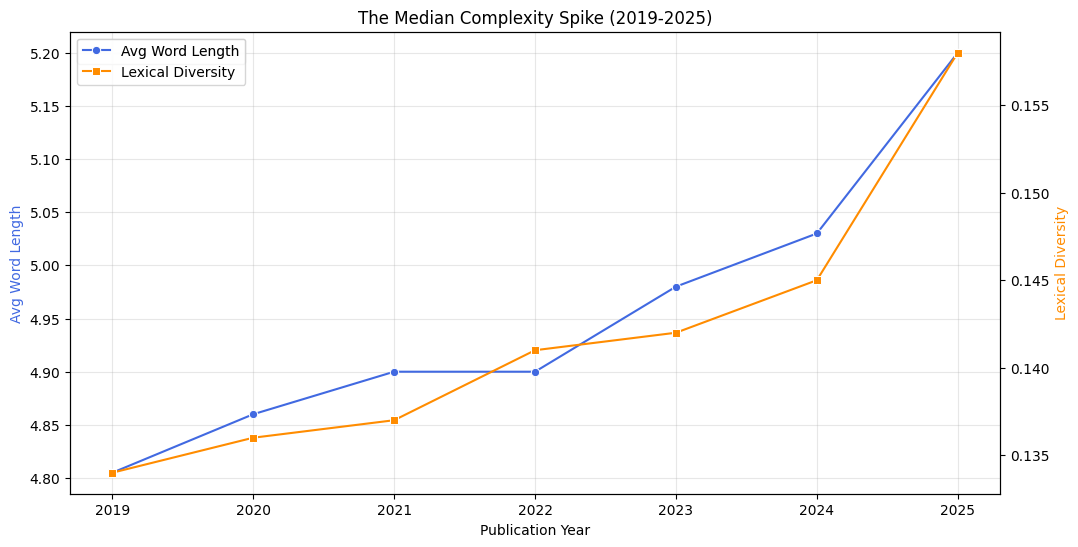

In [47]:
# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
plt.show()